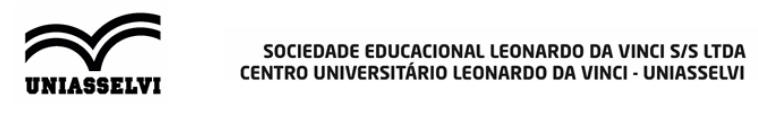

**Nome dos Acadêmicos e Matrículas:** <br> 
Carolina Oliveira Fagundes (3085524) ;<br> 
Fábio Brigido Mesquita (3450160) ;<br> 
Guilherme Arruda Santos (3450160) ;<br> 
Rafaela Maria de Sá Rodrigues (3258059).


# Projeto I - ANÁLISE SOCIOECONÔMICA DO MERCADO DE TRABALHO FORMAL: ADMISSÕES E DISPENSAS - Entrega Etapa I

>## Título

<p align="justify"> 
O presente projeto irá utilizar a base de dados do Anuário Estatístico da Relação Anual de Informações Sociais - RAIS entre os anos de 2010 a 2020. Esta base de dados abrange informações de todos os empregados do ano base em 31/12 e movimentação dos admitidos e desligados. 
Embora os dados estejam disponíveis e previamente estruturados em formato *xlsx no site disponível em https://bi.mte.gov.br/bgcaged/caged_anuario_rais/anuario.htm, as dificuldades do pré-processamento residem na definição das variáveis que deverão ser utilizadas, bem como na correlação das fontes definidas. Por se tratar de uma série histórica, determinados dados e variáveis podem ter sido alterados ou não terem sido obtidos ao longo dos anos por razões técnicas e/ou políticas.



>## Objetivo

Demonstrar o cenário socioeconômico da população com o registro de admissões, de forma a predizer cenários futuros.

>## Especificação Técnica

<p align="justify"> 

**Dataset:** Para desenvolvimento desse projeto, será utilizado dataset específico formado pela base de dados do Anuário Estatístico da RAIS. Os dados estão disponíveis em: https://bi.mte.gov.br/bgcaged/caged_anuario_rais/anuario.htm, por meio do login: basico e senha: 12345678

**Formato:** A base de dados está em formato XLSX, estando divivido em 8 colunas (features) conforme segue: Setor, Região, Faixa Etária, Ano e Governo.

**Variável independente ou preditora: Faixa Etária ( A Faixa Etária foi escolhida como váriavel independente por ser um dos fatores que podem impactar no aumento de desemprego)

**Variável dependente: Ano ( Váriavel que pretende-se prever ao longo do tempo)


**DESCRIÇÃO DAS FEATURES (Características):** 

Região: Região da Federação (letra) - Char(2)

Setor: Código da Atividade Econômica (letra) - VarChar(150)

Ano: Valor do Ano de análise (númerico)

Faixa Etária: Idade das pessoas formalmente registradas (númerico)

Governo - Governo vigente (letra) - Char(2)


**Métodos de Pré-processamento:**  Limpeza e encode da base, onde serão removidos espaços em branco, e transposição de atributos em categóricos ordinais e encode dos dados.

**Tarefa de Aprendizado:** Será aplicado a tarefa de Regressão.

**Modos de aprendizado:** Supervisionado.

**Algoritmos Avaliados:** Randon Forest, Regressão Linear, Rede Neural, K Neighbors Regressor e Gradient boosting.

**Métrica utilizadas:** r2_scores e mean_absolute_error

>## Pré-Processamento 

Importação de todas as bibliotecas que serão utilizadas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
import plotly.offline as py

#Projeto I - ANÁLISE SOCIOECONÔMICA DO MERCADO DE TRABALHO FORMAL: ADMISSÕES E DISPENSAS - Entrega Etapa II

#Importando a base de dados.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving consulta90478463h.xlsx to consulta90478463h (1).xlsx


In [ ]:
import io
data = pd.read_excel('consulta90478463h.xlsx')

#Mostra os dados contidos na base

In [ ]:
data.head(8)

,Setor,Região,Até 17 anos,De 18 a 39 anos,De 40 a 64 anos,65 anos ou mais,Ano,Governo
0,1 - Extrativa Mineral,Norte,32,18974,9844,199,2020,Jair Bolsonaro
1,2 - Indústria de Transformação,Norte,1352,173590,75932,1448,2020,Jair Bolsonaro
2,3 - Servicos Industriais de Utilidade Pública,Norte,149,14745,11415,939,2020,Jair Bolsonaro
3,4 - Construção Civil,Norte,292,71632,42587,1075,2020,Jair Bolsonaro
4,5 - Comércio,Norte,4366,391277,112894,1784,2020,Jair Bolsonaro
5,6 - Serviços,Norte,2631,430726,268918,8670,2020,Jair Bolsonaro
6,7 - Administração Pública,Norte,943,329818,536568,34123,2020,Jair Bolsonaro
7,"8 - Agropecuária, Extração Vegetal, Caça e Pesca",Norte,206,59240,34898,855,2020,Jair Bolsonaro


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Setor            440 non-null    object
 1   Região           440 non-null    object
 2   Até 17 anos      440 non-null    int64 
 3   De 18 a 39 anos  440 non-null    int64 
 4   De 40 a 64 anos  440 non-null    int64 
 5   65 anos ou mais  440 non-null    int64 
 6   Ano              440 non-null    int64 
 7   Governo          440 non-null    object
dtypes: int64(5), object(3)
memory usage: 27.6+ KB


#Relatório dos dados contidos na base em Pandas Profiling


In [ ]:
!pip install -U pandas-profiling -q
from pandas_profiling import ProfileReport
profile = ProfileReport(data, title="Relatório Base de Dados")
profile.to_notebook_iframe()
profile
profile.to_file("Relatório.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#Tratamento da base de dados
Vamos fazer a transposição das faixas etárias para uma única variável afim de obtermos somente um target (1 valor de y) isso vai facilitar o treino dos modelos posteriormente.

In [ ]:
data.columns = ['setor','regiao','faixa01','faixa02','faixa03','faixa04', 'ano', 'governo']
data_novo = pd.DataFrame(columns = ['setor','regiao','faixa_etaria', 'ano','valor','governo'])
for index,row in data.iterrows():
  add1 = [row['setor'],row['regiao'],'Até 17 anos',row['ano'],row['faixa01'],row['governo']]
  add1 = pd.Series(add1,index = data_novo.columns)
  data_novo = data_novo.append(add1,ignore_index = True)

  add2 = [row['setor'],row['regiao'],'De 18 a 39 anos',row['ano'],row['faixa02'],row['governo']]
  add2 = pd.Series(add2,index = data_novo.columns)
  data_novo = data_novo.append(add2,ignore_index = True)

  add3 = [row['setor'],row['regiao'],'De 40 a 64 anos',row['ano'],row['faixa03'],row['governo']]
  add3 = pd.Series(add3,index = data_novo.columns)
  data_novo = data_novo.append(add3,ignore_index = True)

  add4 = [row['setor'],row['regiao'],'65 anos ou mais',row['ano'],row['faixa04'],row['governo']]
  add4 = pd.Series(add4,index = data_novo.columns)
  data_novo = data_novo.append(add4,ignore_index = True)

# Realizando encode nos atributos categóricos ('setor', 'regiao', 'governo' e 'faixa')
Vamos preparar os encoders dos atributos 'setor', 'regiao' e 'governo', que são categóricos não ordinais, cuja ordem não importa e não podem ser ordenados. Caso contrário um modelo de machine learning dará mais importância a para um do que para outro. Vamos transformar estes atributos em categóricos ordinais. Já o atributo 'faixa', que é categórico ordinal (faixa de '18 a 39 anos' é maior que 'até 17 anos', então estes dados deven estar ordenados)

In [ ]:
#Encoder dos dados de faixa etária
encoder_faixa = pd.DataFrame()
encoder_faixa['faixa_etaria'] = ['Até 17 anos','De 18 a 39 anos','De 40 a 64 anos','65 anos ou mais']
encoder_faixa['faixa_etaria_encoded'] = [0,1,2,3]
dc_convert = pd.Series(encoder_faixa.faixa_etaria_encoded.values,index = encoder_faixa.faixa_etaria).to_dict()
dc_unconvert = pd.Series(encoder_faixa.faixa_etaria.values,index = encoder_faixa.faixa_etaria_encoded).to_dict()

faixa_encoded = data_novo[['faixa_etaria']]
faixa_encoded['faixa_etaria'] = faixa_encoded['faixa_etaria'].map(dc_convert)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
#Encoder dos dados da variável 'setor'
encoder_setor = OneHotEncoder()
setor = data_novo[['setor']].values
setor_encoded = encoder_setor.fit_transform(setor)
setor_encoded = pd.DataFrame(setor_encoded.toarray())
setor_encoded.columns = encoder_setor.categories_

In [ ]:
#Encoder dos dados da variável 'regiao'
encoder_regiao = OneHotEncoder()
regiao = data_novo[['regiao']].values
regiao_encoded = encoder_regiao.fit_transform(regiao)
regiao_encoded = pd.DataFrame(regiao_encoded.toarray())
regiao_encoded.columns = encoder_regiao.categories_

In [ ]:
#Encoder dos dados da variável 'governo'
encoder_governo = OneHotEncoder()
governo = data_novo[['governo']].values
governo_encoded = encoder_governo.fit_transform(governo)
governo_encoded = pd.DataFrame(governo_encoded.toarray())
governo_encoded.columns = encoder_governo.categories_

In [ ]:
#As colunas 'ano' e 'valor' não são encodadas pois já são variáveis numéricas.
dados_sem_encode = data_novo[['ano','valor']]

In [ ]:
#Juntando tudo em um dataframe encodado:
data_encoded = pd.DataFrame()
data_encoded = pd.concat([setor_encoded,regiao_encoded,faixa_encoded,governo_encoded,dados_sem_encode],axis=1)

In [ ]:
#Exibindo informações da base encodada
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 20 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   (1 - Extrativa Mineral,)                             1760 non-null   float64
 1   (2 - Indústria de Transformação,)                    1760 non-null   float64
 2   (3 - Servicos Industriais de Utilidade Pública,)     1760 non-null   float64
 3   (4 - Construção Civil,)                              1760 non-null   float64
 4   (5 - Comércio,)                                      1760 non-null   float64
 5   (6 - Serviços,)                                      1760 non-null   float64
 6   (7 - Administração Pública,)                         1760 non-null   float64
 7   (8 - Agropecuária, Extração Vegetal, Caça e Pesca,)  1760 non-null   float64
 8   (Centro-Oeste,)                                      1760 non-null  

# Particionando a base em 20% treino e 80% teste
Entregaremos 20% da base para treino dos modelos.

In [ ]:
#Definindo X e Y
x = data_encoded.iloc[:,0:19].values
y = data_encoded.iloc[:,19].values.reshape(-1,1)
x_treino,x_teste,y_treino,y_teste = train_test_split(x,y,test_size=.20,random_state = 3)

In [ ]:
#Variável responsável por armazenar as métricas de cada modelo aplicado
modelos = []
scores = []

#Projeto I - ANÁLISE SOCIOECONÔMICA DO MERCADO DE TRABALHO FORMAL: ADMISSÕES E DISPENSAS - Entrega Etapa III

Vamos utilizar nos modelos o sklearn pipeline.
O objetivo do pipeline aqui é automatizar parte do preprocessamento de dados juntamente com o treinamento do modelo e geração do modelo final. Em outras palavras, o modelo treinado em pipeline permite que os dados submetidos ao modelo sejam preprocessados de acordo com o tratamento necessário para depois serem submetidos ao modelo em si para previsão dos novos resultados. A vantagem, neste caso é que, ao entregar o resultado, o modelo treinado em pipeline faz a transformação inversa do processamento de dados permitindo que o dado de resposta seja comparável com a base de dados original.

# Aplicando o algoritmo Random Forest

Técnica de classificação e regressão desenvolvida por BREIMAN (2001), que consiste num conjunto de árvores de decisão combinadas para solucionar problemas de classificação. Cada árvore de decisão é construída utilizando uma amostra aleatória inicial dos dados e, a cada divisão desses dados, um subconjunto aleatório de m atributos é utilizado para a escolha dos atributos mais informativos. ​

In [ ]:
from sklearn.ensemble import RandomForestRegressor
escalonador = MinMaxScaler()
regressor = RandomForestRegressor()
pipeline = Pipeline(steps=[('escalonador',escalonador),('regressor',regressor)])
pipeline.fit(x_treino,y_treino)
y_previsao = pipeline.predict(x_teste)
modelos.append("Random Forest")
r2 = r2_score(y_teste,y_previsao)
mae = mean_absolute_error(y_teste,y_previsao)
scores.append(r2)

/usr/local/lib/python3.7/dist-packages/sklearn/pipeline.py:394: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



Gráfico com os modelos de teste do algorítimo Randon Forest

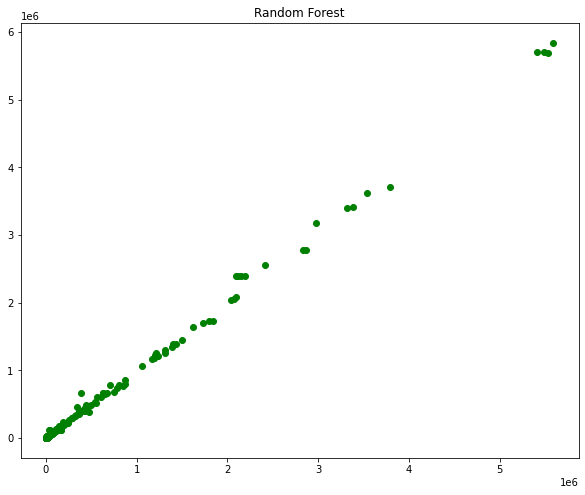

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(y_teste,y_previsao, marker='o', color='g')
plt.title('Random Forest')
plt.savefig('Random Forest.png')

# Aplicando o algoritmo Regressão Linear

Tal método, visa buscar o melhor valor que os coeficientes possam atingir, de maneira que a diferença entre o valor predito pela função e o real, sejam os menores.

In [ ]:
from sklearn.linear_model import LinearRegression
escalonador = MinMaxScaler()
regressor = LinearRegression()
pipeline = Pipeline(steps=[('escalonador',escalonador),('regressor',regressor)])
pipeline.fit(x_treino,y_treino)
y_previsao = pipeline.predict(x_teste)
modelos.append("Regressão Linear")
r2 = r2_score(y_teste,y_previsao)
mae = mean_absolute_error(y_teste,y_previsao)
scores.append(r2)

Gráfico com os modelos de teste do algorítimo Regressão Linear

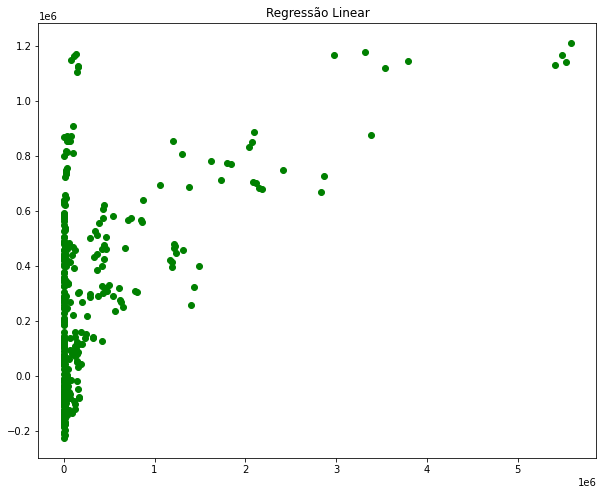

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(y_teste,y_previsao, marker='o', color='g')
plt.title('Regressão Linear')
plt.savefig('Regressão Linear.png')

# Aplicando o algoritmo Rede Neural

Rede Neural Artificial (RNA) pode ser definida como uma estrutura complexa interligada por elementos de processamento simples (neurônios), que possuem a capacidade de realizar operações como cálculos em paralelo, para processamento de dados e representação de conhecimento.

In [ ]:
from sklearn.neural_network import MLPRegressor
escalonador = MinMaxScaler()
regressor = MLPRegressor(hidden_layer_sizes = (20,20,20,20,20,20,20,20,20,20,20,20,20),verbose = 3,max_iter=1000,tol = 1e-7)
pipeline = Pipeline(steps=[('escalonador',escalonador),('regressor',regressor)])
pipeline.fit(x_treino,y_treino)
y_previsao = pipeline.predict(x_teste)
modelos.append("Rede Neural")
r2 = r2_score(y_teste,y_previsao)
mae = mean_absolute_error(y_teste,y_previsao)
scores.append(r2)

/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1599: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Iteration 1, loss = 260472507005.22842407
Iteration 2, loss = 260472409703.64471436
Iteration 3, loss = 260472294202.87939453
Iteration 4, loss = 260472108864.96142578
Iteration 5, loss = 260471841839.62960815
Iteration 6, loss = 260471448984.07369995
Iteration 7, loss = 260470774921.98547363
Iteration 8, loss = 260469614616.58523560
Iteration 9, loss = 260467244533.78250122
Iteration 10, loss = 260462370817.69033813
Iteration 11, loss = 260448971660.75234985
Iteration 12, loss = 260412116747.49465942
Iteration 13, loss = 260296247038.74670410
Iteration 14, loss = 259960634776.33905029
Iteration 15, loss = 258966964405.79394531
Iteration 16, loss = 256283577608.16055298
Iteration 17, loss = 248825618819.88055420
Iteration 18, loss = 233670965108.47354126
Iteration 19, loss = 218999144522.12500000
Iteration 20, loss = 217180648983.21121216
Iteration 21, loss = 213979191143.31817627
Iteration 22, loss = 213251811372.27743530
Iteration 23, loss = 210141197936.53991699
Iteration 24, loss =

Gráfico com os modelos de teste do algorítimo Rede Neural

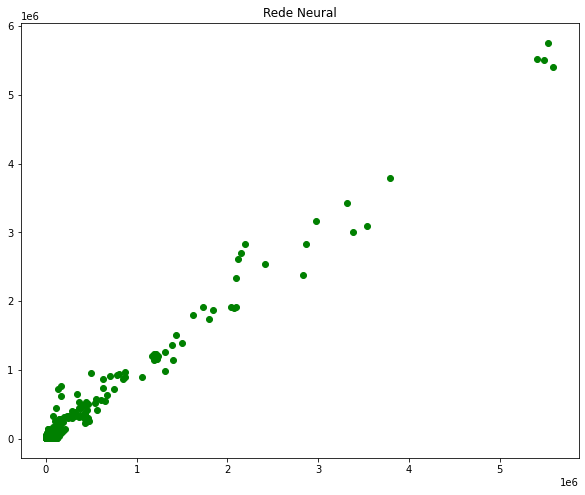

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(y_teste,y_previsao, marker='o', color='g')
plt.title('Rede Neural')
plt.savefig('Rede Neural.png')

# Aplicando o algoritmo K Neighbors Regressor

Método de aprendizagem supervisionada, do tipo classificador, não-paramétrico, que utiliza Lazy Learning e possui três elementos principais: um conjunto de exemplos rotulados (por exemplo, um conjunto de registros armazenados), uma métrica de distância, e o valor de k (o número de vizinhos mais próximos);​

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
escalonador = MinMaxScaler()
regressor = KNeighborsRegressor()
pipeline = Pipeline(steps=[('escalonador',escalonador),('regressor',regressor)])
pipeline.fit(x_treino,y_treino)
y_previsao = pipeline.predict(x_teste)
modelos.append("KNN")
r2 = r2_score(y_teste,y_previsao)
mae = mean_absolute_error(y_teste,y_previsao)
scores.append(r2)

Gráfico com os modelos de teste do algorítimo K Neighbors Regressor

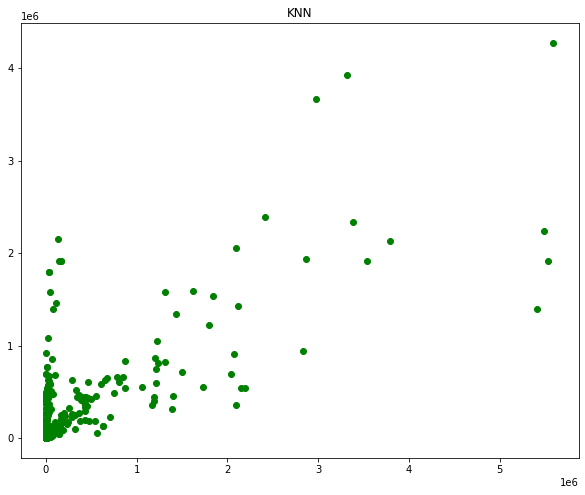

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(y_teste,y_previsao, marker='o', color='g')
plt.title('KNN')
plt.savefig('KNN.png')

# Aplicando o algoritmo Gradient boosting Regressor

Técnica de aprendizado de máquina para problemas de regressão e classificação, produz um modelo de previsão em forma de ensemble de modelos de previsão fracos, geralmente árvores de decisão . Constrói o modelo em etapas, como outros métodos de boosting, e os generaliza, permitindo a otimização de uma função de perda diferenciável arbitrária.​

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
escalonador = MinMaxScaler()
regressor = GradientBoostingRegressor()
pipeline = Pipeline(steps=[('escalonador',escalonador),('regressor',regressor)])
pipeline.fit(x_treino,y_treino)
y_previsao = pipeline.predict(x_teste)
modelos.append("Gradiente Boost Regressor")
r2 = r2_score(y_teste,y_previsao)
mae = mean_absolute_error(y_teste,y_previsao)
scores.append(r2)

/usr/local/lib/python3.7/dist-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



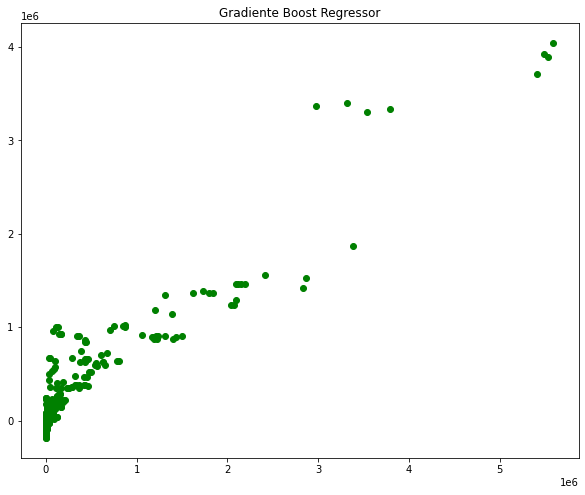

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(y_teste,y_previsao, marker='o', color='g')
plt.title('Gradiente Boost Regressor')
plt.savefig('Gradiente Boost Regressor.png')

# Scores dos modelos

A melhor pontuação possível do r2_score é 1,0 e que também pode ser negativa (porque o modelo pode ser arbitrariamente pior). No geral, quando o y verdadeiro não é constante, um modelo constante que sempre prediz o y médio, desconsiderando os recursos de entrada, obteria uma pontuação de 0,0.

Exibe os resultados de todos os modelos testados

In [ ]:
modelos,scores

(['Random Forest',
  'Regressão Linear',
  'Rede Neural',
  'KNN',
  'Gradiente Boost Regressor'],
 [0.9967726126194814,
  0.2696816980577891,
  0.9818910655816481,
  0.5262695458526969,
  0.8567842471330651])

Exibe as métricas de todos os modelos testados

In [ ]:
metricas = pd.DataFrame()
metricas['modelos'] = modelos
metricas['r2_scores'] = scores
metricas

,modelos,r2_scores
0,Random Forest,0.996773
1,Regressão Linear,0.269682
2,Rede Neural,0.981891
3,KNN,0.526270
4,Gradiente Boost Regressor,0.856784


Ordena os resultados a serem exibidos em ordem ascendente

In [ ]:
metricas = metricas.sort_values(by='r2_scores',ascending = True)

In [ ]:
metricas

,modelos,r2_scores
1,Regressão Linear,0.269682
3,KNN,0.526270
4,Gradiente Boost Regressor,0.856784
2,Rede Neural,0.981891
0,Random Forest,0.996773


Gráfico comparativo de resultados dos modelos testados

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(go.Bar(x = metricas.r2_scores,y = metricas.modelos,orientation = 'h'))
fig.update_layout(
    title="Métrica dos modelos",
    xaxis = dict(
        title = "Correlação de Pearson (R2 Score)"
    ),
    yaxis = dict(
        title = "Algoritmo de ML"
    )
)
fig.show()
fig.write_html('Metricas Modelos.html')